Time Series

In [7]:
! pip install pandas-datareader

In [15]:
! pip install yfinance

     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     ------ --------------------------------- 0.5/3.0 MB 524.3 kB/s eta 0:00:05
     ------ --------------------------------- 0.5/3.0 MB 524.3 kB/s eta 0:00:05
     ------ --------------------------------- 0.5/3.0 MB 524.3 kB/s eta 0:00:05
     ------ --------------------------------- 0.5/3.0 MB 524.3 kB/s eta 0:00:05
     ---------- ----------------------------- 0.8/3.0 MB 399.6 kB/s eta 0:00:06
     ---------- ----------------------------- 0.8/3.0 MB 399.6 kB/s eta 0:00:06
     ---------- ----------------------------- 0.8/3.0 MB 399.6 kB/s eta 0:00:06
     ---------- ----------------------------- 0.8/3.0 MB 399.6 kB/s eta 0:00:06
     

In [19]:
import pandas_datareader as pdr    
import pandas as pd 
from datetime import datetime, timedelta
import yfinance as yf

In [20]:
# Set date range for last 5 years
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Get Tesla data
df_tesla = yf.download('TSLA', start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [55]:
df_tesla.head()
df_tesla.shape

(1256, 6)

<Axes: xlabel='Date'>

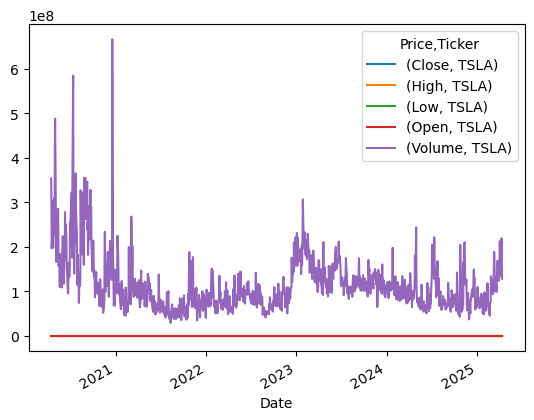

In [22]:
df_tesla.plot()

<Axes: xlabel='Date'>

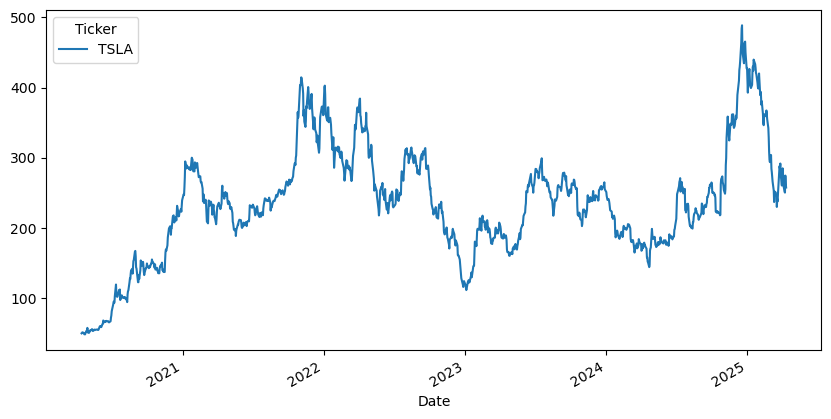

In [25]:
df_tesla['High'].plot(figsize=(10,5))

<Axes: xlabel='Date'>

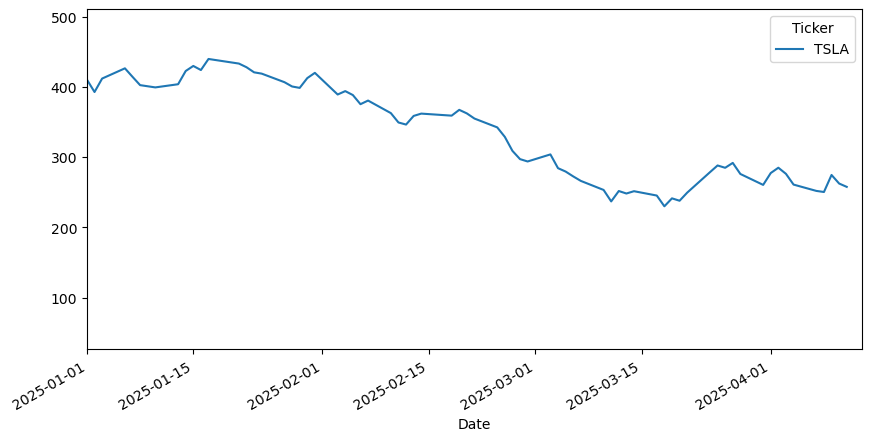

In [27]:
df_tesla['High'].plot(xlim=['2025-01-01','2025-04-13'],figsize=(10,5))

<Axes: xlabel='Date'>

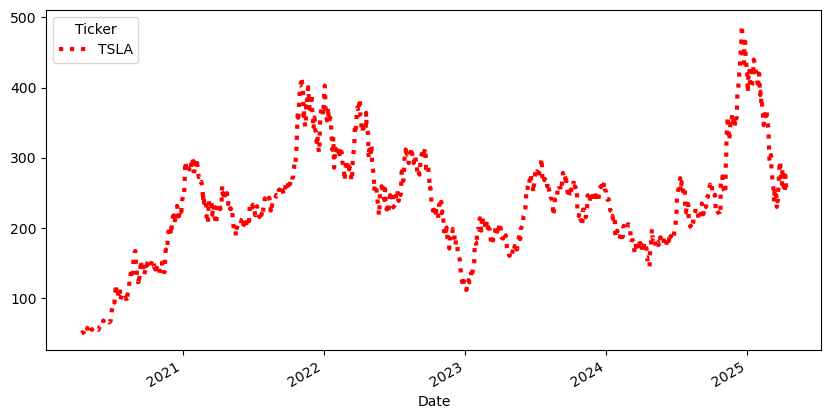

In [34]:
df_tesla['High'].plot(figsize=(10,5),ls=':',color='red',lw=3)

In [35]:
df_tesla.index

DatetimeIndex(['2020-04-15', '2020-04-16', '2020-04-17', '2020-04-20',
               '2020-04-21', '2020-04-22', '2020-04-23', '2020-04-24',
               '2020-04-27', '2020-04-28',
               ...
               '2025-03-31', '2025-04-01', '2025-04-02', '2025-04-03',
               '2025-04-04', '2025-04-07', '2025-04-08', '2025-04-09',
               '2025-04-10', '2025-04-11'],
              dtype='datetime64[ns]', name='Date', length=1256, freq=None)

In [37]:
index=df_tesla.loc['2025-01-01':'2025-04-13'].index
share_close=df_tesla.loc['2025-01-01':'2025-04-13']['Close']

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

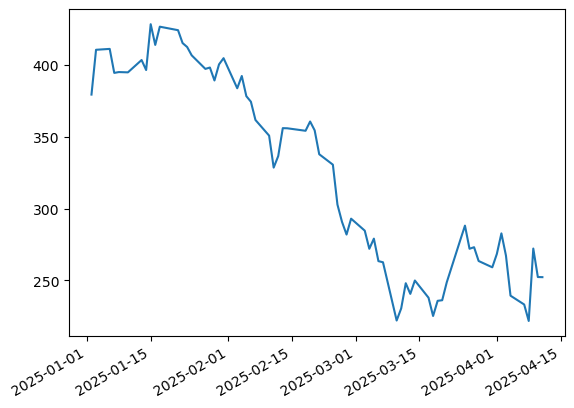

In [ ]:
figure,axis=plt.subplots()
figure.autofmt_xdate()
axis.plot(index,share_close)
plt.show()

In [52]:
df_tesla=df_tesla.reset_index()
df_tesla.head()
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1256 non-null   datetime64[ns]
 1   (index, )       1256 non-null   int64         
 2   (Close, TSLA)   1256 non-null   float64       
 3   (High, TSLA)    1256 non-null   float64       
 4   (Low, TSLA)     1256 non-null   float64       
 5   (Open, TSLA)    1256 non-null   float64       
 6   (Volume, TSLA)  1256 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 68.8 KB


In [53]:
df_tesla=df_tesla.set_index('Date',drop=True)
df_tesla.head()

Price,index,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2020-04-15,0,48.655334,50.208668,47.333332,49.466667,353655000
2020-04-16,1,49.680668,50.630001,47.114666,47.796001,309868500
2020-04-17,2,50.259335,51.663334,49.844002,51.485332,196923000
2020-04-20,3,49.757332,51.037998,47.480667,48.846668,221199000
2020-04-21,4,45.781334,50.222000,44.919334,48.674667,303136500


In [54]:
df_tesla.resample(rule='A').min()

C:\Users\NAVEEN GOWDA\AppData\Local\Temp\ipykernel_1244\2338822268.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_tesla.resample(rule='A').min()


Price,index,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2020-12-31,0,45.781334,48.715332,44.919334,46.733334,52073100
2021-12-31,182,187.666672,188.736664,179.830002,184.183334,29401800
2022-12-31,434,109.099998,116.269997,108.239998,110.349998,41864700
2023-12-31,685,108.099998,111.750000,101.809998,103.000000,65125200
2024-12-31,935,142.050003,144.440002,138.800003,140.559998,37167600
2025-12-31,1187,221.860001,230.100006,214.250000,223.779999,45965400


C:\Users\NAVEEN GOWDA\AppData\Local\Temp\ipykernel_1244\737735323.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  share_close.resample(rule='M').max().plot()


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

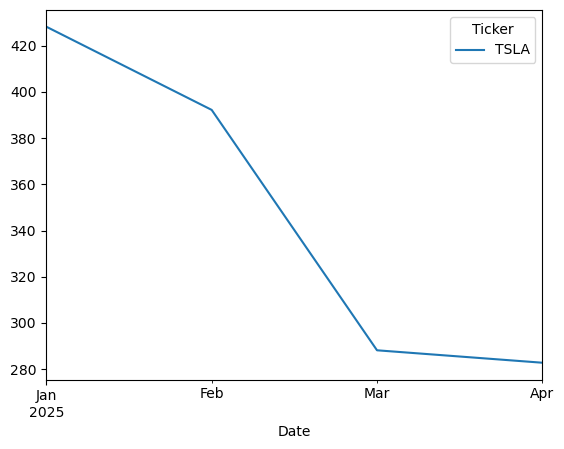

In [61]:
plt.figure(figsize=(12,6))
share_close.resample(rule='M').max().plot()
plt.show()

C:\Users\NAVEEN GOWDA\AppData\Local\Temp\ipykernel_1244\435804237.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  share_close.resample(rule='M').mean().plot(kind='bar')


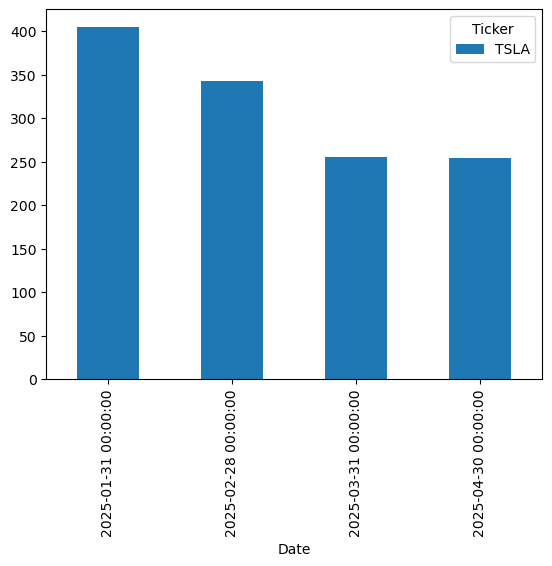

In [71]:

share_close.resample(rule='M').mean().plot(kind='bar')


plt.show()

In [73]:
df_tesla['High'].rolling(5).max().head(10)

Ticker,TSLA
Date,
2020-04-15,NaN
2020-04-16,NaN
2020-04-17,NaN
2020-04-20,NaN
2020-04-21,51.663334
2020-04-22,51.663334
2020-04-23,51.663334
2020-04-24,51.037998
2020-04-27,53.299332


In [81]:
df_tesla['Open:30 days rolling']=df_tesla['Open'].rolling(30).mean()

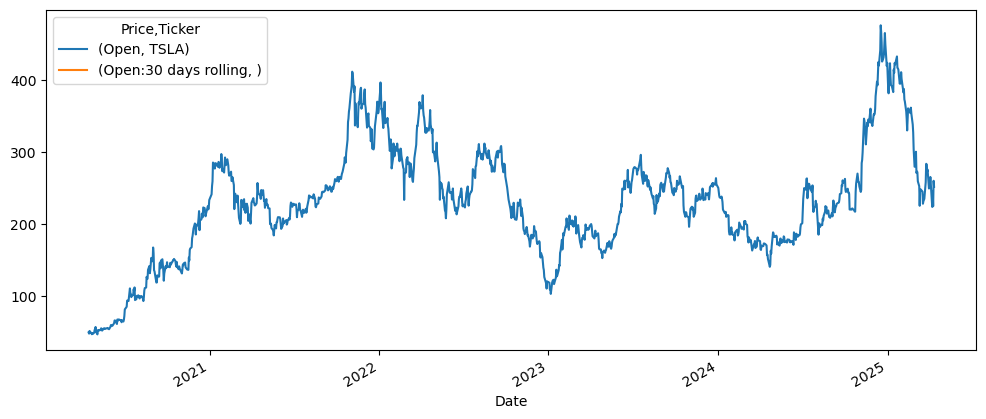

In [82]:
df_tesla[['Open','Open:30 days rolling']].plot(figsize=(12,5))
plt.show()